# Tutorial 2: Architectural Discovery with Block-Based Search

In the previous tutorial, we fine-tuned a known architecture (MLP). But what if the best architecture for our problem is a combination of different diverse layer types?

In this notebook, we'll use SNAC-pack to **discover new architectures** by combining building blocks like **Convolutional layers**, **Attention**, and **MLPs**.

## New Challenge

Since we are building arbitrary structures, our hardware estimator may not be accurate. We will instead optimize for two hardware-agnostic objectives:
1.  **Accuracy** (Maximize)
2.  **Computational Cost (BOPs)** (Minimize)

In [1]:

# imports
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_local_search_separated import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist
import seaborn as sns



# config
N_TRIALS_HYBRID = 20 # can increase this for better results
EPOCHS_HYBRID = 10
SUBSET_SIZE_HYBRID = 20000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-09-01 00:56:38.952968: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000,), y_val shape: (10000,)


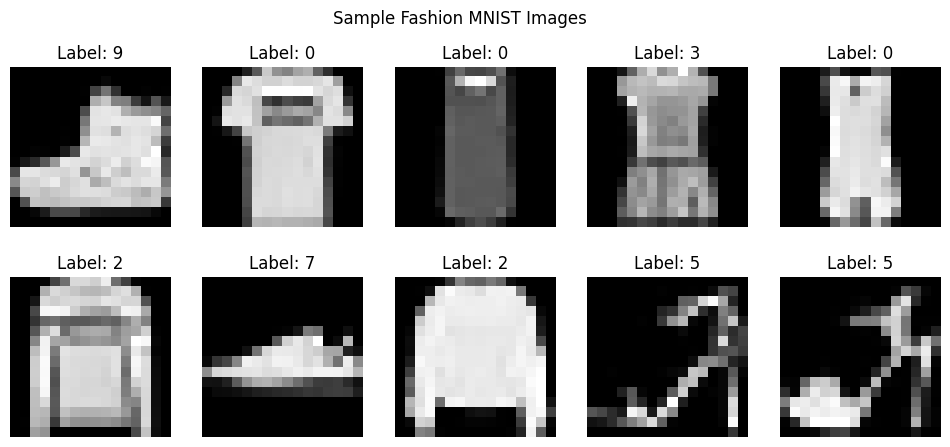

In [2]:
# data loading
x_train_viz, y_train_viz, _, _ = load_and_preprocess_fashion_mnist(
    resize_val=RESIZE_VAL,
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False, 
    one_hot=False
)

# visualize images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample Fashion MNIST Images")
plt.show()

## Global Search: Building with Blocks

We first define a `search_space` in a YAML file. This file provides SNAC-pack with the "Lego bricks" it can use to build and test new architectures. We'll allow it to choose between `Conv`, `MLP`, and `ConvAttn` blocks.


In [3]:

# yaml config
search_space_yaml = """
channel_space: [8, 16, 32]
mlp_width_space: [32, 64, 128]
kernel_space: [1, 3, 5]
act_space: ["ReLU", "GELU", "LeakyRelu"]
norm_space: [null, "batch"]
block_types: ["Conv", "MLP", "None"]
num_blocks: 5
initial_img_size: 16
output_dim: 10
"""

with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")

# objectives
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops']
MAXIMIZE_FLAGS_HYBRID = [True, False]

# run the search
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Global Search...")
print("This will take several minutes...")
print("="*50)

searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

study_hybrid = searcher_hybrid.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='fashion_mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_hybrid.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    one_hot=True,
)

print("\nGlobal Search Complete!")

Created search space configuration file: hybrid_search_space.yaml

Running Part 2: Hybrid Architecture Global Search...
This will take several minutes...

Starting BLOCK Global Search on FASHION_MNIST



[I 2025-09-01 00:56:43,376] A new study created in memory with name: no-name-80393df6-3e8f-4f3e-89c8-f57daca97271


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)


[I 2025-09-01 00:56:47,675] Trial 0 finished with values: [0.7261999845504761, 12189696.0] and parameters: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'Conv', 'b3': 'None', 'b4': 'Conv', 'b0_MLP_units': 0, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 0: Accuracy=0.7262, BOPs=12189696


...

Trial 17: Accuracy=0.6452, BOPs=46792704


[I 2025-09-01 01:00:03,168] Trial 18 finished with values: [0.10000000149011612, 37027840.0] and parameters: {'b0': 'None', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'Conv', 'b4': 'MLP', 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'b2_MLP_units': 2, 'b2_MLP_act': 'LeakyRelu', 'b2_MLP_norm': None, 'b4_MLP_units': 1, 'b4_MLP_act': 'GELU', 'b4_MLP_norm': 'batch', 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 18: Accuracy=0.1000, BOPs=37027840


[I 2025-09-01 01:00:07,679] Trial 19 finished with values: [0.28349998593330383, 43253760.0] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'None', 'b3': 'Conv', 'b4': 'Conv', 'b0_MLP_units': 1, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'b1_MLP_units': 2, 'b1_MLP_act': 'LeakyRelu', 'b1_MLP_norm': 'batch', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 19: Accuracy=0.2835, BOPs=43253760

CSV results saved to ./results/tutorial2_Hybrid_Discovery/block_search_results.csv

🏆 Best model architecture (Trial 15) saved for local search:
   - Source: ./results/tutorial2_Hybrid_Discovery/trial_15_arch.yaml
   - Destination: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml
   - Accuracy: 0.7603

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.7261999845504761, 'bops': 12189696.0}
  Params: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'Conv', 'b3': 'None', 'b4': 'Conv', 'b0_MLP_units': 0, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}

Rank 2 (Trial 14):
  Values: {'performance_metric': 0.691100001335144, 'bops': 11862016.0}
  Params: {'b0': 'None', 'b1': 'MLP', 'b2': 'Conv', 'b3': 

## Analyzing the Global Search Results

The search has finished exploring different architectural combinations. Let's see what it found!

In [4]:


results_df_hybrid = pd.DataFrame(searcher_hybrid.results)

if not results_df_hybrid.empty:
    # inspect architectures
    print("--- Best Discovered Architecture (by Accuracy) ---")
    best_trial_row = results_df_hybrid.loc[results_df_hybrid['performance_metric'].idxmax()]
    print(f"Trial Number: {best_trial_row['trial']}")
    print(f"Accuracy: {best_trial_row['performance_metric']:.4f}")
    print(f"BOPs: {best_trial_row['bops']:.2e}")

    with open(best_trial_row['yaml_path'], 'r') as f:
        best_arch_yaml = yaml.safe_load(f)

    print("\nArchitecture components:")
    for component in best_arch_yaml['architecture']['components']:
        print(f"- Type: {component['block_type']}, Name: {component['name']}")

    # visualize the Pareto front
    print("\n--- Generating Interactive Pareto Front Plot for Hybrid Search ---")
    plot_interactive_2d_pareto(
        results_df_hybrid,
        list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID)),
        save_dir=searcher_hybrid.results_dir
    )
else:
    print("Hybrid search did not yield any results to analyze.")

--- Best Discovered Architecture (by Accuracy) ---
Trial Number: 15
Accuracy: 0.7603
BOPs: 1.85e+08

Architecture components:
- Type: Conv, Name: conv_block_3
- Type: MLP, Name: classifier_head

--- Generating Interactive Pareto Front Plot for Hybrid Search ---


Interactive 2D Pareto front plot saved to ./results/tutorial2_Hybrid_Discovery/interactive_pareto_front_2d.html


## Local Search: Model Compression

Just like before, the global search saved the best model. We will now apply compression to refine the chosen model.


In [1]:
# imports
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_local_search_separated2 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist
import seaborn as sns



# config
N_TRIALS_HYBRID = 6 # can increase this for better results
EPOCHS_HYBRID = 10
SUBSET_SIZE_HYBRID = 30000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-09-01 01:11:02.357758: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# config
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_HYBRID, "local_search_separated")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_HYBRID, 'local_search_settings_separated.yaml')

# QAT settings
local_search_settings = {
    'qat_settings': {
        'epochs': 10, # epochs for fine-tuning
        'precision_pairs': [
            {'total_bits': 32, 'int_bits': 16},
            {'total_bits': 16, 'int_bits': 6},
            {'total_bits': 8, 'int_bits': 3},
            {'total_bits': 4, 'int_bits': 1},
        ]
    }
}

# yaml settings
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created separated local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# best model path
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

# dataset loading
searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

resize_val = searcher_hybrid.search_space.get('initial_img_size', 11)
x_train, y_train, x_val, y_val = load_and_preprocess_fashion_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False,
    one_hot=False
)

# run local search
if os.path.exists(ARCHITECTURE_YAML_PATH):
    # QAT
    _, qat_results_df_hybrid = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR,
        run_pruning=False
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    pruning_results_df_hybrid, qat_results_df_hybrid = pd.DataFrame(), pd.DataFrame()


Created separated local search configuration file: ./results/tutorial2_Hybrid_Discovery/local_search_settings_separated.yaml
Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (30000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (30000,), y_val shape: (10000,)

 STARTING SEPARATED LOCAL SEARCH STAGE 

-------------------- Starting QAT-Only Experiment --------------------

Running QAT for Precision: <32,16>
--> Fine-tuning QAT model for 10 epochs...
Epoch 1/10
235/235 [==============================] - 2s 4ms/step - loss: 7.2412 - accuracy: 0.2192 - val_loss: 4.7450 - val_accuracy: 0.3023
Epoch 2/10
235/235 [==============================] - 1s 3ms/step - loss: 4.4271 - accuracy: 0.3485 - val_loss: 4.1457 - val_accuracy: 0.3746
Epoch 3/10
235/235 [==============================] - 1s 3ms/step - loss: 3.7237 - accuracy: 0.3919 - val_loss: 3.3977 - val_accuracy: 0.4053
Epoch 4/10
235/235 [==============================] - 1s 3ms/step - loss: 3.1937 - accuracy: 

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Epoch 1/10
235/235 [==============================] - 2s 5ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 2/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 3/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 4/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 5/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 6/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 7/10
235/235 [==============================] - 1s 3ms/step - loss: 2.3026 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 

/tmp/ipykernel_1063715/2567215103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Accuracy', data=qat_results_df_hybrid, palette=palette)


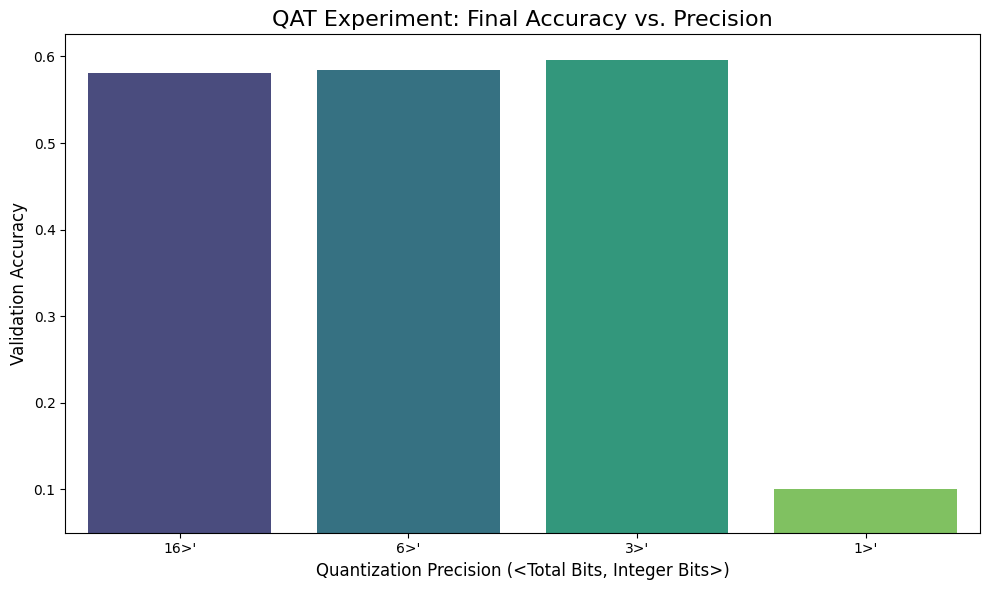

In [3]:
# QAT plotting
if 'qat_results_df_hybrid' in locals() and not qat_results_df_hybrid.empty:
    plt.figure(figsize=(10, 6))
    
    import seaborn as sns
    palette = sns.color_palette("viridis", n_colors=len(qat_results_df_hybrid))
    sns.barplot(x='Precision', y='Accuracy', data=qat_results_df_hybrid, palette=palette)
    
    plt.title('QAT Experiment: Final Accuracy vs. Precision', fontsize=16)
    plt.xlabel('Quantization Precision (<Total Bits, Integer Bits>)', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.ylim(bottom=max(0, qat_results_df_hybrid['Accuracy'].min() - 0.05))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("QAT experiment did not produce results to analyze.")